# Produced-water, sand, and production-chemicals management

This notebook follows water, dispersed oil, dissolved gas, minerals, sand, and production chemicals from the **three-phase separator** to treatment, reuse/recovery, discharge, and emissions. It uses NeqSim Java `master` for thermodynamics and dedicated current-master screening models, with Python for scenario orchestration, compliance time series, consumption accounting, and visualization.

| Management question | NeqSim contribution | Python contribution |
|---|---|---|
| What enters water treatment? | three-phase split and phase properties | water-quality table |
| Can hydrocyclones/deoiling meet duty? | liner/d50/grade-efficiency and treatment train | scenario and flow-weighted OIW |
| Will mixed waters scale or corrode? | compatibility, scale SI, CO₂ corrosion | dose and risk comparison |
| Are hydrate/wax/sand risks controlled? | hydrate equilibrium and sand-erosion screen | chemical/vendor-response assumptions |
| What is recovered, discharged, consumed, emitted? | glycol flash basis and produced-water degassing emissions | mass balance and emissions inventory |

This is concept/operations screening—not a discharge permit, chemical qualification, corrosion management plan, vendor guarantee, or detailed equipment design.


In [1]:
import importlib.util
from importlib.metadata import PackageNotFoundError, version
import os
from pathlib import Path
import subprocess
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/neqsim-value-chain-matplotlib")
SUPPORT_PACKAGES = {
    "jpype": "jpype1",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "scipy": "scipy",
}
missing = [package for module, package in SUPPORT_PACKAGES.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", "--no-cache-dir", *missing],
        check=True,
        timeout=900,
    )
print("Python dependency gate passed.")


Python dependency gate passed.


In [2]:
import hashlib
import json
import math
import os
import platform
from pathlib import Path
import subprocess

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import optimize, stats

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 115, "axes.titlesize": 11, "axes.labelsize": 10})
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4g}")

package_versions = pd.DataFrame({
    "package": ["Python", "JPype", "NumPy", "Pandas", "SciPy", "Matplotlib"],
    "version": [platform.python_version(), version("jpype1"), version("numpy"),
                version("pandas"), version("scipy"), version("matplotlib")],
})
display(package_versions)


,package,version
0,Python,3.12.13
1,JPype,1.7.1
2,NumPy,2.5.1
3,Pandas,3.0.5
4,SciPy,1.18.0
5,Matplotlib,3.11.1


## Reproducible NeqSim Java `master`

The bootstrap builds `master`, records the exact commit and JAR SHA-256, disables wrapper autostart, and proves the current physics-based produced-water hydrocyclone class is loaded from the built JAR.


In [3]:
def run_command(command, *, cwd=None, timeout=1200):
    result = subprocess.run(
        command, cwd=cwd, text=True, stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT, timeout=timeout,
    )
    if result.returncode != 0:
        tail = "\n".join(result.stdout.splitlines()[-80:])
        raise RuntimeError(f"Command failed ({result.returncode}): {command}\n{tail}")
    return result.stdout.strip()

NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
supplied_source = os.environ.get("NEQSIM_SOURCE_ROOT", "").strip()
supplied_jar = os.environ.get("NEQSIM_SOURCE_JAR", "").strip()

if supplied_source and supplied_jar:
    neqsim_source = Path(supplied_source).resolve()
    neqsim_jar = Path(supplied_jar).resolve()
else:
    build_root = Path("/content") if Path("/content").exists() else Path.cwd()
    neqsim_source = build_root / "neqsim-java-master"
    if not neqsim_source.exists():
        run_command([
            "git", "clone", "--depth", "1", "--branch", NEQSIM_SOURCE_REF,
            "https://github.com/equinor/neqsim.git", str(neqsim_source),
        ], timeout=600)
    else:
        run_command(["git", "fetch", "--depth", "1", "origin", NEQSIM_SOURCE_REF],
                    cwd=neqsim_source, timeout=600)
        run_command(["git", "checkout", "--detach", "FETCH_HEAD"], cwd=neqsim_source)
    run_command([
        "./mvnw", "-q", "-DskipTests", "-Dmaven.javadoc.skip=true", "package",
    ], cwd=neqsim_source, timeout=1500)
    built_jars = sorted(
        path for path in (neqsim_source / "target").glob("neqsim-*.jar")
        if "sources" not in path.name and "javadoc" not in path.name
        and not path.name.startswith("original-")
    )
    if not built_jars:
        raise FileNotFoundError("Maven completed but no NeqSim JAR was found.")
    neqsim_jar = built_jars[-1]

if not neqsim_source.is_dir() or not neqsim_jar.is_file():
    raise FileNotFoundError("NeqSim source root or built JAR is missing.")

neqsim_commit = run_command(["git", "rev-parse", "HEAD"], cwd=neqsim_source)
neqsim_jar_sha256 = hashlib.sha256(neqsim_jar.read_bytes()).hexdigest()

os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
if not jpype.isJVMStarted():
    jpype.addClassPath(str(neqsim_jar))
    local_m2 = os.environ.get("NEQSIM_VALIDATION_M2", "").strip()
    if local_m2:
        for dependency in sorted(Path(local_m2).rglob("*.jar")):
            if dependency.resolve() != neqsim_jar:
                jpype.addClassPath(str(dependency))
    jpype.startJVM()

JClass = jpype.JClass
MainOnlyClass = JClass("neqsim.process.equipment.watertreatment.Hydrocyclone")
class_source = str(
    MainOnlyClass.class_.getProtectionDomain().getCodeSource().getLocation()
)
if neqsim_jar.name not in class_source:
    raise RuntimeError("NeqSim classes were not loaded from the source-built JAR.")

provenance_table = pd.DataFrame({
    "item": ["NeqSim source ref", "NeqSim commit", "JAR SHA-256", "Java class source"],
    "resolved value": [NEQSIM_SOURCE_REF, neqsim_commit, neqsim_jar_sha256, class_source],
})
display(provenance_table)


,item,resolved value
0,NeqSim source ref,master
1,NeqSim commit,df68ad7295b9dae6a324d941761a303d9f301fb5
2,JAR SHA-256,45180d03ae275a12bc50342a098c50dae93fe544b69686...
3,Java class source,file:/workspace/scratch/2a202e14c527/neqsim-ja...


## 1. Three-phase separation defines every downstream load

Gas leaving with produced water drives methane/CO₂ emissions and safety loads. Oil carry-under drives oil-in-water treatment. Water rate and properties size hydrocyclones and determine chemical consumption. The example uses an SRK-CPA fluid and a NeqSim three-phase separator.


In [4]:
SystemSrkCPA = JClass("neqsim.thermo.system.SystemSrkCPAstatoil")
Stream = JClass("neqsim.process.equipment.stream.Stream")
ThreePhaseSeparator = JClass("neqsim.process.equipment.separator.ThreePhaseSeparator")

feed_fluid = SystemSrkCPA(273.15 + 76.0, 32.0)
for component, amount in {"methane": 12.0, "CO2": 1.2, "ethane": 1.0, "propane": .8,
                          "n-heptane": 10.0, "nC10": 6.0, "water": 69.0}.items():
    feed_fluid.addComponent(component, amount)
feed_fluid.setMixingRule(10); feed_fluid.setMultiPhaseCheck(True)
pw_feed = Stream("Production manifold", feed_fluid); pw_feed.setFlowRate(180000.0, "kg/hr")
separator = ThreePhaseSeparator("1st-stage three-phase separator", pw_feed)
separator.setEntrainment(0.002, "volume", "product", "aqueous", "oil")
separator.run()

gas_out = separator.getGasOutStream(); oil_out = separator.getOilOutStream(); water_out = separator.getWaterOutStream()
phase_split = pd.DataFrame({"outlet": ["gas", "oil", "produced water"],
                            "kg_h": [gas_out.getFlowRate("kg/hr"), oil_out.getFlowRate("kg/hr"), water_out.getFlowRate("kg/hr")],
                            "m3_h": [gas_out.getFlowRate("m3/hr"), oil_out.getFlowRate("m3/hr"), water_out.getFlowRate("m3/hr")]})
water_rate_m3h = float(water_out.getFlowRate("m3/hr"))
water_density = float(water_out.getFluid().getDensity("kg/m3"))
water_viscosity = float(water_out.getFluid().getViscosity("kg/msec"))
assert water_rate_m3h > 0 and abs(phase_split.kg_h.sum()-pw_feed.getFlowRate("kg/hr"))/pw_feed.getFlowRate("kg/hr") < .02
display(phase_split.round(2))
display(pd.DataFrame({"water property": ["density", "viscosity", "temperature", "pressure"],
                      "value": [water_density, water_viscosity, water_out.getTemperature("C"), water_out.getPressure("bara")],
                      "unit": ["kg/m³", "Pa·s", "°C", "bara"]}))


,outlet,kg_h,m3_h
0,gas,1.337e+04,561
1,oil,1.014e+05,159
2,produced water,6.519e+04,66.61


,water property,value,unit
0,density,978.7,kg/m³
1,viscosity,0.0003703,Pa·s
2,temperature,76,°C
3,pressure,32,bara


## 2. Water quality and hydrocyclone/deoiling screening

The current-master hydrocyclone model links fluid properties, liner size/count, pressure drop, droplet-size distribution, cut size $d_{50}$, turndown, and oil-removal efficiency. Its grade-efficiency relation is

$$\eta(d)=1-\exp\left[-0.693\left(\frac{d}{d_{50}}\right)^n\right]$$

Oil-in-water (OIW) is an operational input because a bulk thermodynamic phase split does not predict the dispersed-droplet distribution or analyzer response.


,metric,value,unit
0,Water duty,66.61,m³/h
1,Active liners,14,count
2,Spare liners,2,count
3,d50,8.02,µm
4,DSD efficiency,93.19,%
5,Design capacity,70,m³/h
6,Minimum operating flow,28,m³/h
7,PDR factor,0.98,-


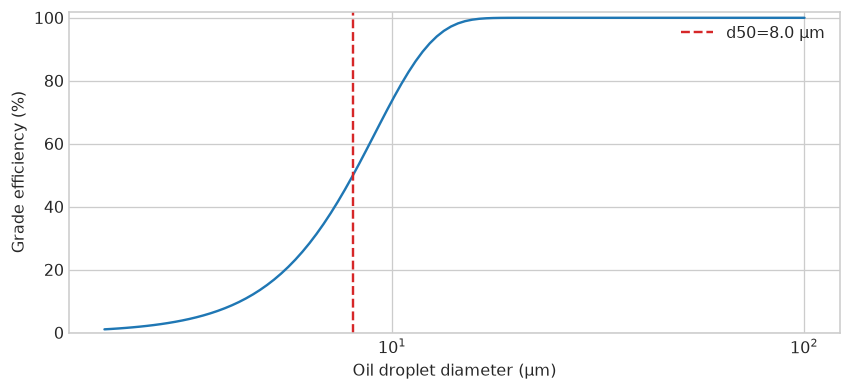

In [5]:
Hydrocyclone = JClass("neqsim.process.equipment.watertreatment.Hydrocyclone")
hc = Hydrocyclone("HC-2101")
hc.setLinerDiameterMm(35.0); hc.calcNumberOfLiners(water_rate_m3h); hc.setNumberOfSpareLiners(2)
hc.setPressureDropBar(5.0); hc.setPDR(1.8); hc.setInletOilConcentration(650.0)
hc.setWaterDensity(water_density); hc.setWaterViscosity(water_viscosity); hc.setOilDensity(835.0)
hc.setDv50Microns(28.0); hc.setGeometricStdDev(2.2)
d50 = hc.calcD50FromConditions(); hc.setD50Microns(d50); efficiency = hc.calcEfficiencyFromDSD()
hc_summary = pd.DataFrame({"metric": ["Water duty", "Active liners", "Spare liners", "d50", "DSD efficiency",
                                             "Design capacity", "Minimum operating flow", "PDR factor"],
                                 "value": [water_rate_m3h, hc.getNumberOfLiners(), hc.getNumberOfSpareLiners(), d50,
                                           100*efficiency, hc.getMaxDesignCapacityM3h(), hc.getMinOperatingFlowM3h(),
                                           hc.getPDREfficiencyFactor()],
                                 "unit": ["m³/h", "count", "count", "µm", "%", "m³/h", "m³/h", "-"]})
assert 0 < efficiency < 1 and hc.getNumberOfLiners() > 0
display(hc_summary.round(2))

droplets = np.geomspace(2, 100, 100)
grade = np.array([hc.getEfficiencyForDropletSize(float(d)) for d in droplets])
plt.figure(figsize=(7.5, 3.5)); plt.semilogx(droplets, 100*grade)
plt.axvline(d50, color="C3", linestyle="--", label=f"d50={d50:.1f} µm")
plt.xlabel("Oil droplet diameter (µm)"); plt.ylabel("Grade efficiency (%)"); plt.ylim(0, 102); plt.legend(); plt.tight_layout(); plt.show()


## 3. Treatment train and discharge constraint

Hydrocyclone removal is followed by flotation and polishing. The notebook evaluates a configurable **30 mg/L monthly flow-weighted dispersed-oil performance standard**, consistent with [OSPAR Recommendation 2001/1 as amended](https://www.ospar.org/documents?v=32591) and its [2020/02 amendment](https://www.ospar.org/documents?v=43939). Actual permits, approved methods, sampling frequency, dissolved components, risk-based assessment, and jurisdiction-specific limits remain controlling.


,stage,inlet_mg_L,outlet_mg_L,removal_pct
0,Hydrocyclone,650,44.25,93.19
1,Compact flotation,44.25,9.73,78
2,Polishing,9.73,5.35,45


,monthly KPI,value,unit
0,Flow-weighted OIW,5.395,mg/L
1,Dispersed oil,253.8,kg/month
2,30 mg/L screen,True,pass/fail


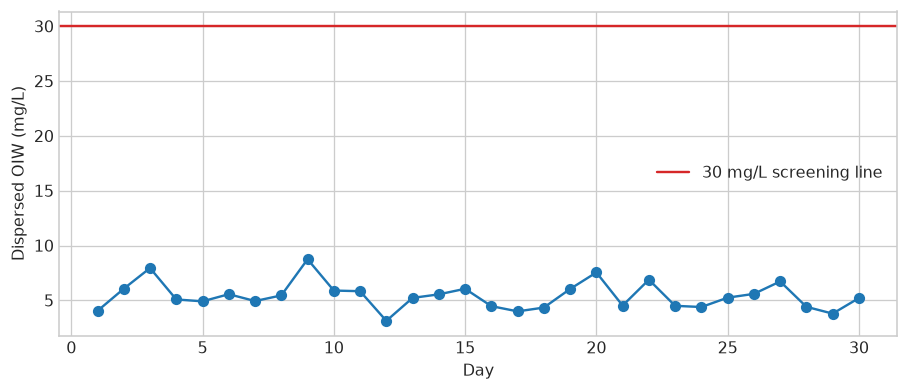

In [6]:
TreatmentTrain = JClass("neqsim.process.equipment.watertreatment.ProducedWaterTreatmentTrain")
Stage = JClass("neqsim.process.equipment.watertreatment.ProducedWaterTreatmentTrain$WaterTreatmentStage")
StageType = JClass("neqsim.process.equipment.watertreatment.ProducedWaterTreatmentTrain$StageType")
train = TreatmentTrain("PW treatment")
train.clearStages(); train.setWaterFlowRate(water_rate_m3h); train.setInletOilConcentration(650.0)
train.addStage(Stage("Hydrocyclone", StageType.HYDROCYCLONE, float(efficiency)))
train.addStage(Stage("Compact flotation", StageType.FLOTATION, .78))
train.addStage(Stage("Polishing", StageType.SKIM_TANK, .45)); train.run()
stage_table = pd.DataFrame([{"stage": str(s.getName()), "inlet_mg_L": s.getInletOIW(),
                             "outlet_mg_L": s.getOutletOIW(), "removal_pct": 100*s.getEfficiency()}
                            for s in train.getStages()])
display(stage_table.round(2))

rng = np.random.default_rng(17); days = np.arange(1, 31)
flow = water_rate_m3h*24*rng.normal(1.0, .08, len(days))
oiw = np.maximum(0, train.getOilInWaterMgL()*rng.lognormal(0, .22, len(days)))
oiw[[8, 19]] *= [2.1, 1.7]
monthly_weighted_oiw = np.average(oiw, weights=flow)
discharge = pd.DataFrame({"day": days, "water_m3": flow, "OIW_mg_L": oiw,
                          "dispersed_oil_kg": flow*oiw/1000})
assert np.isclose(discharge.dispersed_oil_kg.sum(), (flow*oiw/1000).sum())
display(pd.DataFrame({"monthly KPI": ["Flow-weighted OIW", "Dispersed oil", "30 mg/L screen"],
                      "value": [monthly_weighted_oiw, discharge.dispersed_oil_kg.sum(), monthly_weighted_oiw <= 30],
                      "unit": ["mg/L", "kg/month", "pass/fail"]}))

plt.figure(figsize=(8, 3.5)); plt.plot(days, oiw, "o-"); plt.axhline(30, color="C3", label="30 mg/L screening line")
plt.xlabel("Day"); plt.ylabel("Dispersed OIW (mg/L)"); plt.legend(); plt.tight_layout(); plt.show()


## 4. Water compatibility and mineral-scale control

Produced/formation water and injection water are screened across mixing ratios for calcite, barite, celestite, anhydrite, and siderite saturation indices. Positive SI indicates thermodynamic supersaturation, not deposition rate. Scale-inhibitor dose and squeeze life require bottle/dynamic tests, kinetics, adsorption/retention, residence time, and vendor qualification.


,injection_water_pct,SI_CaCO3,SI_BaSO4,SI_SrSO4,SI_CaSO4,SI_FeCO3
0,0,-50.94,1.731,-3.513,-1.083,-51.05
1,10,-50.86,2.424,-2.621,-0.495,-50.97
2,20,-50.79,2.83,-2.015,-0.194,-50.89
3,30,-50.73,3.15,-1.494,0.021,-50.83
4,40,-50.68,3.421,-1.018,0.186,-50.77
5,50,-50.64,3.653,-0.578,0.313,-50.73
6,60,-50.62,3.844,-0.172,0.401,-50.71
7,70,-50.62,3.984,0.191,0.44,-50.72
8,80,-50.67,4.044,0.497,0.408,-50.78
9,90,-50.81,3.947,0.716,0.251,-50.97


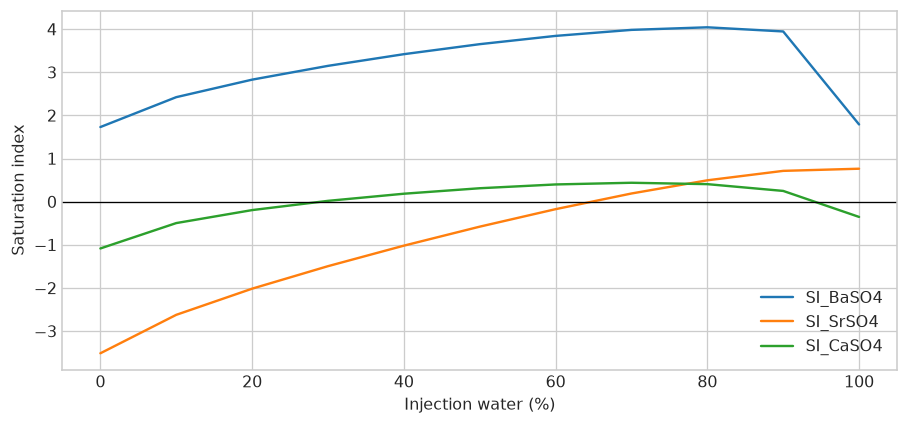

In [7]:
Compatibility = JClass("neqsim.pvtsimulation.flowassurance.WaterCompatibilityScreener")
compat = Compatibility()
compat.setFormationWater(18000, 850, 420, 75, 2200, 120, 95000, 76, 32, 2.4, 5.8)
compat.setInjectionWater(480, 0.4, 35, 0.2, 140, 2800, 35000, 20, 150, .02, 7.2)
compat.setFormationWaterMgNa(2400, 55000); compat.setInjectionWaterMgNa(1200, 10500)
compat.setMixingRatios(jpype.JArray(jpype.JDouble)(np.linspace(0, 100, 11).tolist())); compat.calculate()
compatibility = pd.DataFrame([{"injection_water_pct": r.injectionWaterPct, "SI_CaCO3": r.siCaCO3,
                               "SI_BaSO4": r.siBaSO4, "SI_SrSO4": r.siSrSO4,
                               "SI_CaSO4": r.siCaSO4, "SI_FeCO3": r.siFeCO3}
                              for r in compat.getResults()])
display(compatibility.round(3))

si_cols = [c for c in compatibility if c.startswith("SI_")]
compatibility.set_index("injection_water_pct")[["SI_BaSO4", "SI_SrSO4", "SI_CaSO4"]].plot(figsize=(8, 3.8))
plt.axhline(0, color="black", linewidth=.8); plt.ylabel("Saturation index"); plt.xlabel("Injection water (%)")
plt.tight_layout(); plt.show()


## 5. Corrosion and inhibitor screening

NeqSim couples an electrolyte/aqueous calculation to a CO₂-corrosion screen. Inhibitor efficiency is an input from qualified tests; this cell shows the consequence of assumed efficiency rather than predicting chemical performance from molecular structure.


In [8]:
Corrosion = JClass("neqsim.pvtsimulation.flowassurance.CO2CorrosionAnalyzer")
corrosion_rows = []
for efficiency_assumed in [0.0, .70, .90, .95]:
    corr = Corrosion(68.0, 28.0)
    corr.setCO2MoleFractionInGas(.075); corr.setH2SMoleFractionInGas(0.0)
    corr.setFlowVelocity(2.4); corr.setPipeDiameter(.20); corr.setInhibitorEfficiency(efficiency_assumed)
    corr.run()
    corrosion_rows.append({"assumed_inhibitor_efficiency": efficiency_assumed,
                           "corrosion_rate_mm_y": corr.getCorrosionRate(),
                           "baseline_mm_y": corr.getBaselineCorrosionRate(),
                           "pH": corr.getAqueousPH(), "severity": str(corr.getCorrosionSeverity())})
corrosion = pd.DataFrame(corrosion_rows)
assert (corrosion.corrosion_rate_mm_y >= 0).all()
display(corrosion.round(3))


,assumed_inhibitor_efficiency,corrosion_rate_mm_y,baseline_mm_y,pH,severity
0,0,55.88,56.7,4.05,Very High
1,0.7,16.77,56.7,4.05,Very High
2,0.9,5.588,56.7,4.05,Very High
3,0.95,2.794,56.7,4.05,Very High


## 6. Hydrate, wax, and inhibitor boundaries

NeqSim calculates hydrate equilibrium from a wet-gas composition. The MEG dose below is a **planning assumption** used to close consumption/recovery balances; inhibitor effectiveness needs a validated thermodynamic/kinetic design. Wax inhibitor response is also a lab/vendor input: NeqSim can predict wax phase behavior, but a ppm dose cannot be inferred from thermodynamics alone.


,distance_km,pressure_bara,actual_C,hydrate_C,margin_C,risk
0,0,120,24,21.83,2.17,HIGH
1,10,105,15,21.16,-6.16,CRITICAL
2,25,80,8,19.64,-11.64,CRITICAL
3,40,55,5,17.18,-12.18,CRITICAL


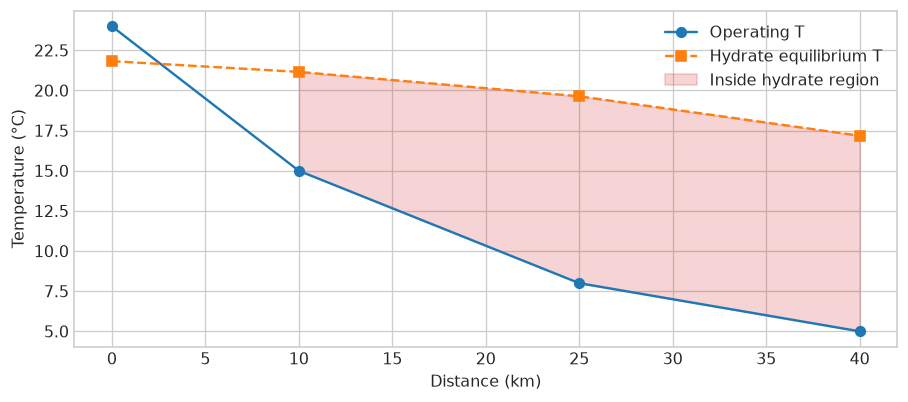

,hazard,NeqSim output,chemical input needed,screening assumption
0,hydrate,equilibrium curve / subcooling,MEG wt% or kinetic-inhibitor performance,20 wt% MEG on associated water
1,wax,wax phase/WAT with characterized oil,lab-qualified ppm-response curve,450 ppm on oil


In [9]:
HydrateMapper = JClass("neqsim.pvtsimulation.flowassurance.HydrateRiskMapper")
wet_gas = SystemSrkCPA(273.15 + 22.0, 120.0)
for c, n in {"methane": .84, "ethane": .07, "propane": .04, "CO2": .02, "water": .03}.items(): wet_gas.addComponent(c, n)
wet_gas.setMixingRule(10); wet_gas.setMultiPhaseCheck(True); wet_gas.setHydrateCheck(True)
mapper = HydrateMapper(wet_gas)
for distance, pressure, temperature in [(0, 120, 24), (10, 105, 15), (25, 80, 8), (40, 55, 5)]:
    mapper.addProfilePoint(distance, pressure, temperature)
hydrate_profile = mapper.calculate()
hydrate = pd.DataFrame([{"distance_km": p.distanceKm, "pressure_bara": p.pressureBara,
                         "actual_C": p.actualTemperatureC, "hydrate_C": p.hydrateTemperatureC,
                         "margin_C": p.subcoolingC, "risk": str(p.riskLevel)}
                        for p in hydrate_profile.getPoints()])
assert np.isfinite(hydrate.hydrate_C).all(), "Hydrate equilibrium calculation did not converge"
display(hydrate.round(2))

plt.figure(figsize=(8, 3.6)); plt.plot(hydrate.distance_km, hydrate.actual_C, "o-", label="Operating T")
plt.plot(hydrate.distance_km, hydrate.hydrate_C, "s--", label="Hydrate equilibrium T")
plt.fill_between(hydrate.distance_km, hydrate.actual_C, hydrate.hydrate_C,
                 where=hydrate.actual_C < hydrate.hydrate_C, color="C3", alpha=.2, label="Inside hydrate region")
plt.xlabel("Distance (km)"); plt.ylabel("Temperature (°C)"); plt.legend(); plt.tight_layout(); plt.show()

flow_assurance_basis = pd.DataFrame({
    "hazard": ["hydrate", "wax"], "NeqSim output": ["equilibrium curve / subcooling", "wax phase/WAT with characterized oil"],
    "chemical input needed": ["MEG wt% or kinetic-inhibitor performance", "lab-qualified ppm-response curve"],
    "screening assumption": ["20 wt% MEG on associated water", "450 ppm on oil"]})
display(flow_assurance_basis)


## 7. Sand handling and erosion

Sand production is not a thermodynamic phase-equilibrium problem. NeqSim uses mixture properties, geometry, velocity, particle size/density, wall material, and sand rate to screen erosional velocity and bend erosion. A desander, accumulation/cleanout, produced-solids characterization, and erosion monitoring still require dedicated design evidence.


In [10]:
Erosion = JClass("neqsim.pvtsimulation.flowassurance.ErosionPredictionCalculator")
erosion_rows = []
for sand_kg_d in [0, 5, 20, 50]:
    er = Erosion(); er.setMixtureDensity(180.0); er.setGasDensity(45.0); er.setLiquidDensity(820.0)
    er.setMixtureVelocity(7.0); er.setGasVelocity(8.5); er.setLiquidVelocity(1.5)
    er.setPipeDiameter(.15); er.setWallThickness(12.0); er.setMixtureViscosity(.0012)
    er.setGeometry("bend"); er.setBendRadiusRatio(1.5); er.setPipeMaterial("carbon steel")
    er.setSandRate(float(sand_kg_d)); er.setSandParticleDiameter(.25); er.setSandParticleDensity(2650.0)
    er.calculate()
    erosion_rows.append({"sand_kg_d": sand_kg_d, "erosional_velocity_m_s": er.getErosionalVelocity(),
                         "velocity_ratio": er.getVelocityRatio(), "erosion_mm_y": er.getErosionRate(),
                         "risk": str(er.getRiskLevel())})
erosion = pd.DataFrame(erosion_rows)
assert (erosion.erosion_mm_y >= 0).all()
display(erosion.round(4))


,sand_kg_d,erosional_velocity_m_s,velocity_ratio,erosion_mm_y,risk
0,0,9.093,0.7699,0,low
1,5,9.093,0.7699,0.0021,low
2,20,9.093,0.7699,0.0085,low
3,50,9.093,0.7699,0.0213,low


## 8. MEG/TEG recovery and chemical consumption

The recovery balance distinguishes circulating inventory from make-up. NeqSim thermodynamics and process modules support glycol/water flashes and regeneration studies; here the transparent planning balance uses specified rich/lean concentrations and recovery. TEG is included because dehydration solvent recovery competes for heating/cooling and emissions, even when the produced-water train itself primarily handles MEG.


In [11]:
oil_rate_m3d = float(oil_out.getFlowRate("m3/hr"))*24
water_rate_m3d = water_rate_m3h*24
chemical_basis = pd.DataFrame([
    ["demulsifier", 8.0, water_rate_m3d, 1e-3, .0, 2.8],
    ["scale inhibitor", 12.0, water_rate_m3d, 1e-3, .0, 3.2],
    ["corrosion inhibitor", 18.0, water_rate_m3d+oil_rate_m3d, 1e-3, .0, 3.6],
    ["wax inhibitor", 450.0, oil_rate_m3d, 1e-3, .0, 3.9],
    ["MEG circulation", 200000.0, water_rate_m3d, 1e-3, .95, 2.1],
    ["TEG circulation", 1200.0, phase_split.loc[0, "kg_h"]*24/1000, 1e-3, .985, 2.4],
], columns=["chemical", "dose_basis", "carrier_per_day", "conversion_to_kg", "recovery_fraction", "embedded_kgCO2e_per_kg"])
chemical_basis["circulation_kg_d"] = chemical_basis.dose_basis*chemical_basis.carrier_per_day*chemical_basis.conversion_to_kg
chemical_basis["makeup_kg_d"] = chemical_basis.circulation_kg_d*(1-chemical_basis.recovery_fraction)
chemical_basis["embedded_kgCO2e_d"] = chemical_basis.makeup_kg_d*chemical_basis.embedded_kgCO2e_per_kg
assert (chemical_basis.makeup_kg_d <= chemical_basis.circulation_kg_d + 1e-9).all()
display(chemical_basis[["chemical", "circulation_kg_d", "recovery_fraction", "makeup_kg_d", "embedded_kgCO2e_d"]].round(2))


,chemical,circulation_kg_d,recovery_fraction,makeup_kg_d,embedded_kgCO2e_d
0,demulsifier,12.79,0,12.79,35.81
1,scale inhibitor,19.18,0,19.18,61.38
2,corrosion inhibitor,97.46,0,97.46,350.9
3,wax inhibitor,"1,717",0,"1,717","6,697"
4,MEG circulation,3.197e+05,0.95,1.599e+04,3.357e+04
5,TEG circulation,385.2,0.98,5.78,13.87


## 9. Produced-water degassing emissions and total inventory

Dissolved methane and CO₂ released through pressure reduction can dominate operational produced-water emissions. NeqSim `ProducedWaterDegassingSystem` estimates staged degasser/CFU/caisson releases. Chemical embedded factors remain explicit scenario inputs; replace them with governed supplier/product life-cycle data and the facility’s actual routing (recovery, flare, vent, or treatment).


,source,kgCO2e_d
0,PW degassing (NeqSim),9.952e+05
1,Chemical make-up (scenario factors),4.073e+04


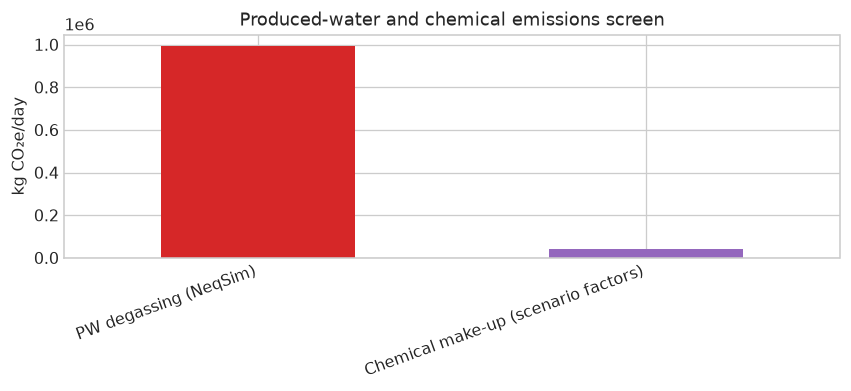

In [12]:
PWEmissions = JClass("neqsim.process.equipment.util.ProducedWaterDegassingSystem")
pw_emissions = PWEmissions("Produced-water degassing")
pw_emissions.setWaterFlowRate(water_rate_m3h, "m3/hr"); pw_emissions.setWaterTemperature(76.0, "C")
pw_emissions.setInletPressure(32.0, "bara"); pw_emissions.setDegasserPressure(4.0, "bara")
pw_emissions.setCFUPressure(1.2, "bara"); pw_emissions.setSalinity(8.0, "wt%")
pw_emissions.setDissolvedGasComposition(jpype.JArray(jpype.JString)(["CO2", "methane", "ethane", "propane"]),
                                        jpype.JArray(jpype.JDouble)([.48, .46, .045, .015]))
pw_emissions.run()
direct_co2e_kg_d = float(pw_emissions.getTotalCO2Equivalents("kg/hr"))*24
inventory = pd.DataFrame({"source": ["PW degassing (NeqSim)", "Chemical make-up (scenario factors)"],
                          "kgCO2e_d": [direct_co2e_kg_d, chemical_basis.embedded_kgCO2e_d.sum()]})
assert (inventory.kgCO2e_d >= 0).all()
display(inventory.round(2))
ax = inventory.set_index("source").kgCO2e_d.plot.bar(figsize=(7.5, 3.5), color=["#d62728", "#9467bd"])
ax.set(ylabel="kg CO₂e/day", xlabel="", title="Produced-water and chemical emissions screen")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()


## 10. Integrated operating window

No single KPI proves acceptable produced-water management. OIW, dispersed-oil mass, dissolved substances, chemical environmental classification, scale/corrosion control, sand/erosion, glycol losses, and greenhouse-gas routing must be managed together.


In [13]:
operating_window = pd.DataFrame([
    ["Three-phase separation", f"{water_rate_m3h:.1f} m³/h water", "sets all downstream loads"],
    ["Hydrocyclone", f"{hc.getNumberOfLiners()} active + {hc.getNumberOfSpareLiners()} spare", f"d50 {d50:.1f} µm; validate vendor curve"],
    ["Discharge", f"{monthly_weighted_oiw:.1f} mg/L flow-weighted OIW", "check permit, method, sampling and RBA"],
    ["Scale", f"worst {compat.getWorstCaseScale()} SI={compat.getWorstCaseSI():.2f}", "qualify inhibitor / water strategy"],
    ["Corrosion", f"{corrosion.corrosion_rate_mm_y.min():.3f}–{corrosion.corrosion_rate_mm_y.max():.3f} mm/y", "verify material, monitoring and inhibitor"],
    ["Hydrate", f"minimum margin {hydrate.margin_C.min():.1f} °C", "thermal/MEG/operating strategy"],
    ["Sand", f"up to {erosion.erosion_mm_y.max():.4f} mm/y in screen", "desander, cleanout and erosion monitoring"],
    ["Chemicals", f"{chemical_basis.makeup_kg_d.sum():,.0f} kg/d make-up", "optimize dose and recovery; track discharge"],
    ["Emissions", f"{inventory.kgCO2e_d.sum():,.0f} kgCO2e/d", "route gas; use governed factors"],
])
operating_window.columns = ["area", "screening result", "controlled next step"]
display(operating_window)
assert len(neqsim_jar_sha256) == 64 and water_rate_m3h > 0 and np.isfinite(inventory.kgCO2e_d).all()
print("Engineering checks passed: separation, treatment, discharge, chemistry, sand, consumption, recovery, and emissions are linked.")


Engineering checks passed: separation, treatment, discharge, chemistry, sand, consumption, recovery, and emissions are linked.


,area,screening result,controlled next step
0,Three-phase separation,66.6 m³/h water,sets all downstream loads
1,Hydrocyclone,14 active + 2 spare,d50 8.0 µm; validate vendor curve
2,Discharge,5.4 mg/L flow-weighted OIW,"check permit, method, sampling and RBA"
3,Scale,worst BaSO4 SI=4.04,qualify inhibitor / water strategy
4,Corrosion,2.794–55.882 mm/y,"verify material, monitoring and inhibitor"
5,Hydrate,minimum margin -12.2 °C,thermal/MEG/operating strategy
6,Sand,up to 0.0213 mm/y in screen,"desander, cleanout and erosion monitoring"
7,Chemicals,"17,838 kg/d make-up",optimize dose and recovery; track discharge
8,Emissions,"1,035,896 kgCO2e/d",route gas; use governed factors


## Limits and next steps

- Calibrate separator carry-under, droplet-size distributions, hydrocyclone performance, analyzer bias/drift, and flotation response with field/vendor data.
- Extend water quality beyond ions/OIW to dissolved hydrocarbons, metals, NORM, suspended solids, residual chemicals, toxicity/risk, and injection specifications.
- Couple full wax characterization, inhibitor response tests, corrosion/scale kinetics, MEG/TEG regeneration duties, salt accumulation, reclaiming waste, and logistics.
- Replace the illustrative 30-day discharge series and chemical/emission factors with permit-approved measurements and governed inventories.
